# Problem Solving Agents: Uninformed Search

## Problem-Solving Agents & State Space

When the correct action to take is not immediately obvious, an agent may need to to plan ahead: to consider a sequence of actions that form a path to a goal state.

Such an agent is called a **problem-solving agent**, and the computational process it undertakes is called **search**.

Problem-solving agents use atomic representations - states of the world are considered as wholes, with no internal structure visible to the problem-solving algorithms

We are going to build the **Goal-Based agents** that can plan ahead to solve problems.


       

A **classical problem-solving agent**:

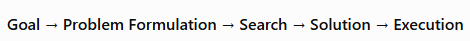


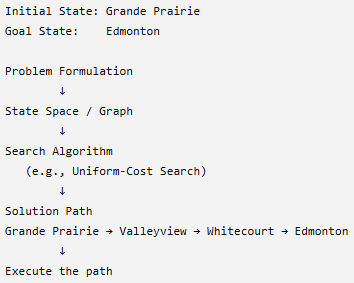

### Romania navigation problem Example

In particular, we examine n*avigation problem/ route finding problem*.

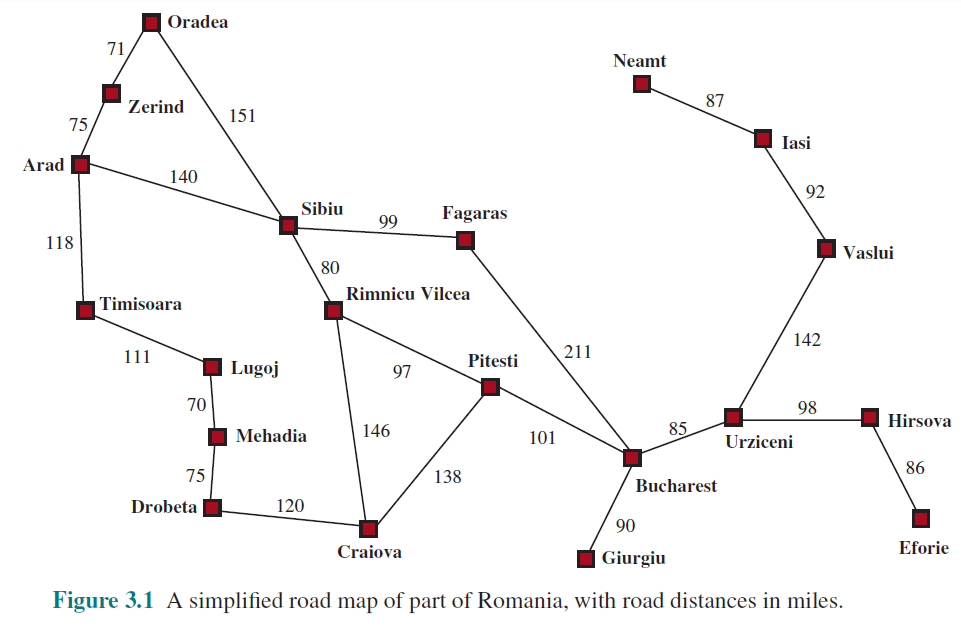

We consider only the simplest environments: single agent, fully observable, deterministic, static, discrete, and known



#### 1. Problem Definition - class Problem

1. We must begin by **precisely defining problems** -> `class Problem` - how we define a Problem in general 

 **!!!** Explore the `class Problem`

2. `class Problem` == The *abstract class* for a formal problem. 
* You should subclass     this and implement the methods `actions` and `result`, and possibly  ` __init__, goal_test`, and `path_cost`. 
* The *state space* should be included in a subclass
* Then you will create instances of your subclass and solve them with the various search functions.

3. `class  GraphProblem(Problem)` == The problem of searching a graph (the state space  ==  a graph) from one node to another
* The state space is stored as nested dictionaries

    `G={'node1':{'neighbor1_of_Node1':distance_from_Node1_to_neighbor1_of_Node1,..},
       .....}`

In [1]:
from src.graphProblemClass import GraphProblem

The graph data -> stored in the nested dictionary `romaniaData`

In [2]:
from data.RomaniaMapData import romaniaData

In [3]:
romaniaData

{'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
 'Bucharest': {'Urziceni': 85, 'Pitesti': 101, 'Giurgiu': 90, 'Fagaras': 211},
 'Craiova': {'Drobeta': 120, 'Rimnicu': 146, 'Pitesti': 138},
 'Drobeta': {'Mehadia': 75},
 'Eforie': {'Hirsova': 86},
 'Fagaras': {'Sibiu': 99},
 'Hirsova': {'Urziceni': 98},
 'Iasi': {'Vaslui': 92, 'Neamt': 87},
 'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
 'Oradea': {'Zerind': 71, 'Sibiu': 151},
 'Pitesti': {'Rimnicu': 97},
 'Rimnicu': {'Sibiu': 80},
 'Urziceni': {'Vaslui': 142}}

4. Based on this dictionary we need to build a graph
* !!! Check the `Graph class`

A graph connects nodes (vertices) by edges (links). Each edge can also have a length associated with it. 

* The constructor call is something like:

        `g = Graph({'A': {'B': 1, 'C': 2})`

this makes a graph with 3 nodes, A, B, and C, with an edge of length 1 from     A to B,  and an edge of length 2 from A to C. 
    
This makes an `undirected graph`, so inverse links are also added. 

If you add more links with `g.connect('B', 'C', 3)`, then inverse link is also added. 
* You can use `g.nodes()` to get a list of nodes,
* `g.get('A')` to get a dict of links out of A, 
* and `g.get('A', 'B')` to get the length of the link from A to B.

In [4]:
from src.graphClass import Graph

In [5]:
romaniaGraph = Graph(romaniaData) # create a graph object from the romania dictionary

In [6]:
romaniaGraph.nodes()

['Vaslui',
 'Timisoara',
 'Giurgiu',
 'Oradea',
 'Sibiu',
 'Pitesti',
 'Iasi',
 'Lugoj',
 'Hirsova',
 'Fagaras',
 'Arad',
 'Zerind',
 'Rimnicu',
 'Mehadia',
 'Urziceni',
 'Drobeta',
 'Craiova',
 'Neamt',
 'Bucharest',
 'Eforie']

In [7]:
romaniaGraph.get('Arad')

{'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118}

In [8]:
romaniaGraph.get('Arad','Zerind')

75

Let's try to show the graph

In [9]:
from pyvis.network import Network 

In [10]:
net = Network( heading="Lab3. Examples of Romania Navigation Problem",
                bgcolor ="#242020",
                font_color = "white",
                height = "750px",
                width = "100%"
) # do this

In [11]:
net.add_nodes(romaniaGraph.nodes(), title=[str(node) for node in romaniaGraph.nodes()])

In [12]:
nodeColors={
    "start":"red",
    "goal": "green",
    "frontier": "orange",
    "expanded":"pink"
}

In [13]:
for node in net.nodes:
    if node['id']=='Arad':
        node["color"]=nodeColors["start"]
    elif node['id']=='Bucharest':
        node["color"]=nodeColors["goal"]
    

In [14]:
romaniaGraph.graph_dict

{'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
 'Bucharest': {'Urziceni': 85, 'Pitesti': 101, 'Giurgiu': 90, 'Fagaras': 211},
 'Craiova': {'Drobeta': 120, 'Rimnicu': 146, 'Pitesti': 138},
 'Drobeta': {'Mehadia': 75, 'Craiova': 120},
 'Eforie': {'Hirsova': 86},
 'Fagaras': {'Sibiu': 99, 'Bucharest': 211},
 'Hirsova': {'Urziceni': 98, 'Eforie': 86},
 'Iasi': {'Vaslui': 92, 'Neamt': 87},
 'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
 'Oradea': {'Zerind': 71, 'Sibiu': 151},
 'Pitesti': {'Rimnicu': 97, 'Bucharest': 101, 'Craiova': 138},
 'Rimnicu': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
 'Urziceni': {'Vaslui': 142, 'Bucharest': 85, 'Hirsova': 98},
 'Zerind': {'Arad': 75, 'Oradea': 71},
 'Sibiu': {'Arad': 140, 'Fagaras': 99, 'Oradea': 151, 'Rimnicu': 80},
 'Timisoara': {'Arad': 118, 'Lugoj': 111},
 'Giurgiu': {'Bucharest': 90},
 'Mehadia': {'Drobeta': 75, 'Lugoj': 70},
 'Vaslui': {'Iasi': 92, 'Urziceni': 142},
 'Neamt': {'Iasi': 87}}

In [15]:
edges=[]
edges_labels=[]

for node_source in romaniaGraph.nodes():
    for node_target, dist in romaniaGraph.get(node_source).items():
        if set((node_source,node_target)) not in edges:
            net.add_edge(node_source,node_target, label=str(dist))
            edges.append(set((node_source,node_target)))
            edges_labels.append(str(dist))
            
    
    

In [16]:
edges_labels[:5]

['92', '142', '118', '111', '90']

In [17]:
edges[:5]

[{'Iasi', 'Vaslui'},
 {'Urziceni', 'Vaslui'},
 {'Arad', 'Timisoara'},
 {'Lugoj', 'Timisoara'},
 {'Bucharest', 'Giurgiu'}]

In [18]:
net.edges

[{'label': '92', 'from': 'Vaslui', 'to': 'Iasi'},
 {'label': '142', 'from': 'Vaslui', 'to': 'Urziceni'},
 {'label': '118', 'from': 'Timisoara', 'to': 'Arad'},
 {'label': '111', 'from': 'Timisoara', 'to': 'Lugoj'},
 {'label': '90', 'from': 'Giurgiu', 'to': 'Bucharest'},
 {'label': '71', 'from': 'Oradea', 'to': 'Zerind'},
 {'label': '151', 'from': 'Oradea', 'to': 'Sibiu'},
 {'label': '140', 'from': 'Sibiu', 'to': 'Arad'},
 {'label': '99', 'from': 'Sibiu', 'to': 'Fagaras'},
 {'label': '80', 'from': 'Sibiu', 'to': 'Rimnicu'},
 {'label': '97', 'from': 'Pitesti', 'to': 'Rimnicu'},
 {'label': '101', 'from': 'Pitesti', 'to': 'Bucharest'},
 {'label': '138', 'from': 'Pitesti', 'to': 'Craiova'},
 {'label': '87', 'from': 'Iasi', 'to': 'Neamt'},
 {'label': '70', 'from': 'Lugoj', 'to': 'Mehadia'},
 {'label': '98', 'from': 'Hirsova', 'to': 'Urziceni'},
 {'label': '86', 'from': 'Hirsova', 'to': 'Eforie'},
 {'label': '211', 'from': 'Fagaras', 'to': 'Bucharest'},
 {'label': '75', 'from': 'Arad', 'to': '

In [19]:
net.show("graph1.html", notebook=False)

graph1.html


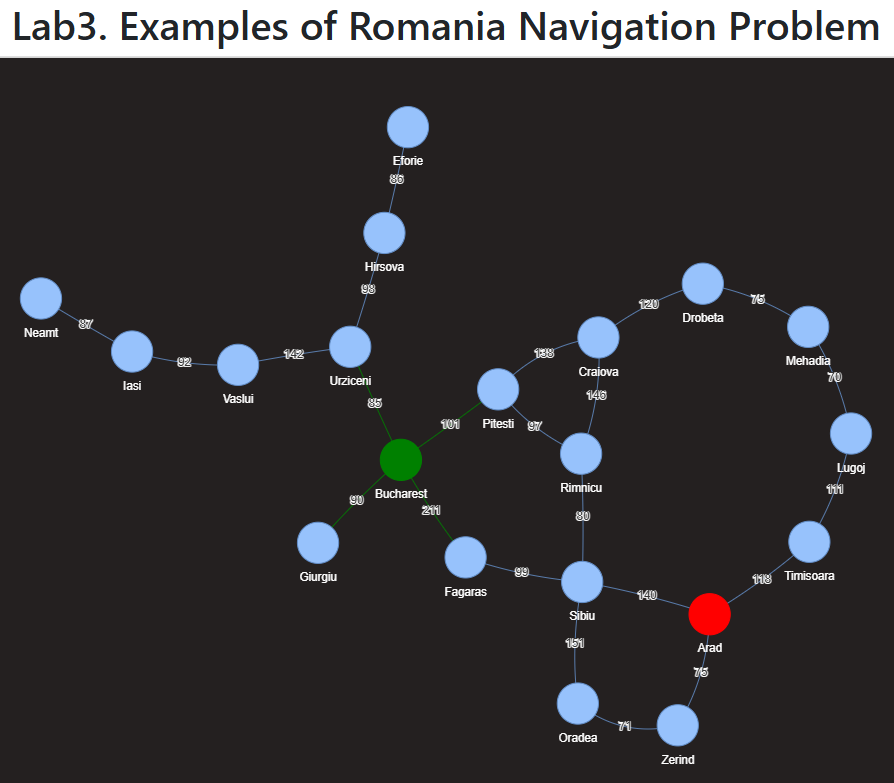

### The vacumm world example

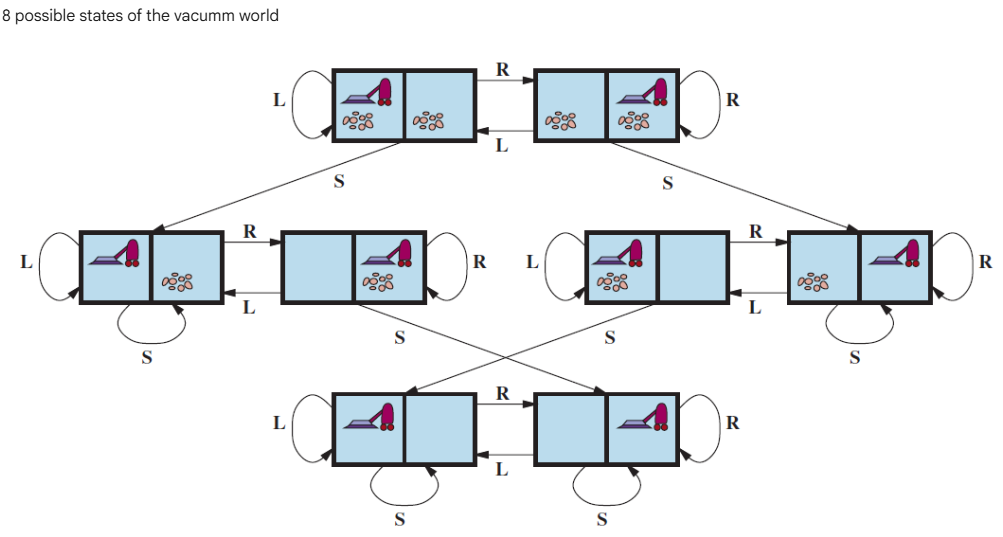

Each state is represented as:

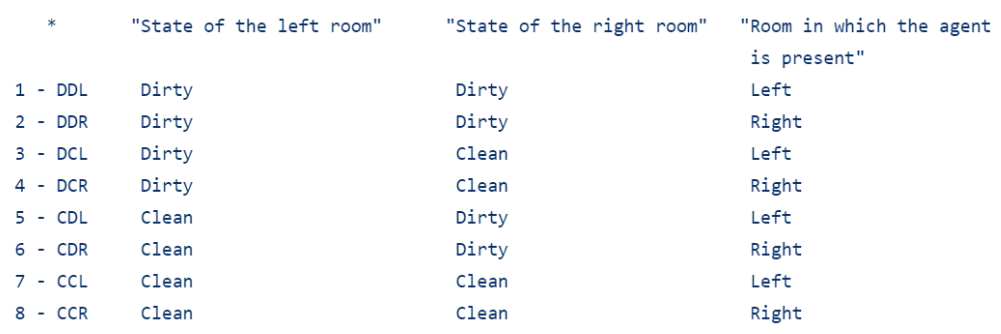

In [20]:
from data.vacuumWorldData import vacuumWorld

In [21]:
vacuumWorld # the state space description

{'DDL': {'Suck': 'CDL', 'Left': 'DDL', 'Right': 'DDR'},
 'DDR': {'Suck': 'DCR', 'Left': 'DDL', 'Right': 'DDR'},
 'DCL': {'Suck': 'CCL', 'Left': 'DCL', 'Right': 'DCR'},
 'DCR': {'Suck': 'DCR', 'Left': 'DCL', 'Right': 'DCR'},
 'CDL': {'Suck': 'CDL', 'Left': 'CDL', 'Right': 'CDR'},
 'CDR': {'Suck': 'CCR', 'Left': 'CDL', 'Right': 'CDR'},
 'CCL': {'Suck': 'CCL', 'Left': 'CCL', 'Right': 'CCR'},
 'CCR': {'Suck': 'CCR', 'Left': 'CCL', 'Right': 'CCR'}}

The vacuumWorld dictionary has a different structure:


*{node1: {action1: neighbour1ofNode1,...}}*


When we need the following:
*{node1: {neighbour1ofNode1:action1,...}}*,

Like our Romania Graph:

*{'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},*

*'Bucharest': {'Urziceni': 85, 'Pitesti': 101, 'Giurgiu': 90, 'Fagaras': 211},*
 
 *....}*

In [22]:
from src.vacuumGraphClass import vacuumGraph

In [23]:
from data.vacuumWorldData import vacuumStatesLocations

In [24]:
vacuumWorldGraph = vacuumGraph(vacuumWorld, vacuumStatesLocations())

The  purpose of ```python vacuumStatesLocations() ``` is to randomly assign a 2D location to every state and return those state-location pairs as a dictionary.

The function does this:

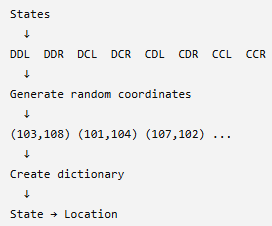

In [25]:
vacuumWorldGraph.graph_dict

{'DDL': {'CDL': 1, 'DDL': 1, 'DDR': 1},
 'DDR': {'DCR': 1, 'DDL': 1, 'DDR': 1},
 'DCL': {'CCL': 1, 'DCL': 1, 'DCR': 1},
 'DCR': {'DCR': 1, 'DCL': 1},
 'CDL': {'CDL': 1, 'CDR': 1},
 'CDR': {'CCR': 1, 'CDL': 1, 'CDR': 1},
 'CCL': {'CCL': 1, 'CCR': 1},
 'CCR': {'CCR': 1, 'CCL': 1}}

In [26]:
vacuumWorldGraph.origin

{'DDL': {'Suck': 'CDL', 'Left': 'DDL', 'Right': 'DDR'},
 'DDR': {'Suck': 'DCR', 'Left': 'DDL', 'Right': 'DDR'},
 'DCL': {'Suck': 'CCL', 'Left': 'DCL', 'Right': 'DCR'},
 'DCR': {'Suck': 'DCR', 'Left': 'DCL', 'Right': 'DCR'},
 'CDL': {'Suck': 'CDL', 'Left': 'CDL', 'Right': 'CDR'},
 'CDR': {'Suck': 'CCR', 'Left': 'CDL', 'Right': 'CDR'},
 'CCL': {'Suck': 'CCL', 'Left': 'CCL', 'Right': 'CCR'},
 'CCR': {'Suck': 'CCR', 'Left': 'CCL', 'Right': 'CCR'}}

In [27]:
vacuumWorldGraph.get(("CDR"))

{'CCR': 1, 'CDL': 1, 'CDR': 1}

In [28]:
vacuumWorldGraph.getLocation(("CDR"))

(109, 108)

In [29]:
net_VacuumWorld = Network( heading="Lab3. Examples of Vacuum World Problem",
                bgcolor ="#242020",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed = True, 
) # do this

In [30]:
vacuumWorldGraph.nodes()

['DDR', 'CDL', 'CDR', 'DCR', 'CCR', 'CCL', 'DDL', 'DCL']

In [31]:
#we can't do this: net_VacuumWorld.add_nodes(vacuumWorldGraph.nodes())

# we need to add nodes with their locations, so we can visualize them in the right place

for node in vacuumWorldGraph.nodes():
    x,y=vacuumWorldGraph.getLocation(node)
    #net_VacuumWorld.add_node(node, x=x, y=y, physics=False)
    net_VacuumWorld.add_node(node, x=x, y=y)

Let's create edges based on the *vacuumWorld* data

In [32]:
vacuumWorld

{'DDL': {'Suck': 'CDL', 'Left': 'DDL', 'Right': 'DDR'},
 'DDR': {'Suck': 'DCR', 'Left': 'DDL', 'Right': 'DDR'},
 'DCL': {'Suck': 'CCL', 'Left': 'DCL', 'Right': 'DCR'},
 'DCR': {'Suck': 'DCR', 'Left': 'DCL', 'Right': 'DCR'},
 'CDL': {'Suck': 'CDL', 'Left': 'CDL', 'Right': 'CDR'},
 'CDR': {'Suck': 'CCR', 'Left': 'CDL', 'Right': 'CDR'},
 'CCL': {'Suck': 'CCL', 'Left': 'CCL', 'Right': 'CCR'},
 'CCR': {'Suck': 'CCR', 'Left': 'CCL', 'Right': 'CCR'}}

In [33]:
edge_weights = {(k, v2) : k2 for k, v in vacuumWorld.items() for k2, v2 in v.items()}#actions
edge_weights

{('DDL', 'CDL'): 'Suck',
 ('DDL', 'DDL'): 'Left',
 ('DDL', 'DDR'): 'Right',
 ('DDR', 'DCR'): 'Suck',
 ('DDR', 'DDL'): 'Left',
 ('DDR', 'DDR'): 'Right',
 ('DCL', 'CCL'): 'Suck',
 ('DCL', 'DCL'): 'Left',
 ('DCL', 'DCR'): 'Right',
 ('DCR', 'DCR'): 'Right',
 ('DCR', 'DCL'): 'Left',
 ('CDL', 'CDL'): 'Left',
 ('CDL', 'CDR'): 'Right',
 ('CDR', 'CCR'): 'Suck',
 ('CDR', 'CDL'): 'Left',
 ('CDR', 'CDR'): 'Right',
 ('CCL', 'CCL'): 'Left',
 ('CCL', 'CCR'): 'Right',
 ('CCR', 'CCR'): 'Right',
 ('CCR', 'CCL'): 'Left'}

In [34]:
len(edge_weights)

20

In [35]:
edges=[]
for node_source in vacuumWorldGraph.nodes():
    for node_target, actCost in vacuumWorldGraph.get(node_source).items():
        # check if the edge has already been added (since this is an undirected graph, we only want to add each edge once)
        if (node_source,node_target) not in edges:
           
            net_VacuumWorld.add_edge(node_source,node_target, label=edge_weights[(node_source,node_target)])
            edges.append((node_source,node_target))

In [36]:
len(edges)

20

In [37]:
edges

[('DDR', 'DCR'),
 ('DDR', 'DDL'),
 ('DDR', 'DDR'),
 ('CDL', 'CDL'),
 ('CDL', 'CDR'),
 ('CDR', 'CCR'),
 ('CDR', 'CDL'),
 ('CDR', 'CDR'),
 ('DCR', 'DCR'),
 ('DCR', 'DCL'),
 ('CCR', 'CCR'),
 ('CCR', 'CCL'),
 ('CCL', 'CCL'),
 ('CCL', 'CCR'),
 ('DDL', 'CDL'),
 ('DDL', 'DDL'),
 ('DDL', 'DDR'),
 ('DCL', 'CCL'),
 ('DCL', 'DCL'),
 ('DCL', 'DCR')]

In [38]:
net_VacuumWorld.show("graph2.html", notebook=False)

graph2.html


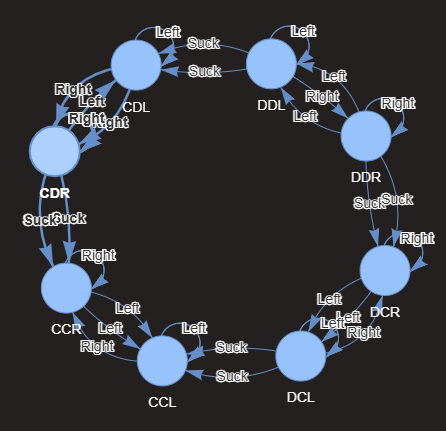

## Search Algorithms

A ***search algorithm*** takes a **search problem** as **input** and returns a **solution**, or an indication of failure.


We consider algorithms that superimpose a search tree over the statespace graph, forming various paths from the initial state, trying to find a path that reaches a goal state


Each node in the search tree corresponds to a state in the state space and the edges in the search tree correspond to actions.


The root of the tree corresponds to the initial state of the problem.

!!! It is important to understand the distinction between the state space and the search tree:

* The state space describes the (possibly infinite) set of states in the world, and the actions that allow transitions from one state to another.

* The search tree describes paths between these states, reaching towards the goal



### Data structure - Node class

Search algorithms require a data structure to keep track of the search tree.

A node in the tree is represented by a data structure - `Node class`:

* Contains a `pointer to the parent` (the node that this is a successor of) and to the actual `state for this node`. 
* !!! Note that if a state is arrived at by two paths, then there are two nodes with the same state. 
* Also includes the `action` that got us to this state, 
* and  the `total path_cost `(also known as g) to reach the node. 


**!!!** You will not need to subclass this class.

### Simple Problem Solving (SPS) Agent - class SimpleProblemSolvingAgentProgram

The process of a problem-solving agent involves 4 key stages: 
1. **Goal formulation**: The agent defines the desired state it wants to achieve (such as a chess agent winning a game or a delivery robot reaching its destination).
2. **Problem formulation**: The agent translates the goal into a formal problem definition, including the *initial state*, the possible *actions*, and the *costs* associated with those actions.
3. **Search**: The agent uses *search algorithms* to explore potential sequences of actions *to find a path from the initial state to the goal state*.
4. **Execution**: The agent *carries out the sequence of actions* determined during the search phase

*Components of a problem formulation*:

**!!!** Explore `the Problem class` AGAIN

To define a problem, the agent uses the following formal components: 
* **Initial state**: The starting point of the problem, representing the current configuration of the environment.
* **Actions**: A set of possible operations or moves the agent can perform. For example, a vacuum cleaner agent might have the actions "move left," "move right," and "suck dirt".
* **Transition model**: A description of the resulting state after performing an action from a given state. This allows the agent to simulate future outcomes.
* **Goal test**: A way to determine if a given state is the desired goal state.
* **Path cost**: A function that assigns a numerical cost to a sequence of actions, which the agent can use to find the most efficient solution. 

!!! Explore the `class SimpleProblemSolvingAgentProgram` from (src/problemSolvingAgentProgramClass.py) to idenify components and stages mentioned above

* `State` is an abstract representation of the state of the world, 
* and `seq` is the list of actions required to get to a particular state from the initial state(root)

#### SPS Agent for the Vacuum Problem

1. Explore the derived class `VacuumProblem(Problem)` for our Vacuum World example

First, let's try VacuumProblem

In [39]:
from src.vacuumProblemClass import VacuumProblem

In [40]:
initState="DDL"
initState

'DDL'

In [41]:
goalState=["CCL","CCR"]
goalState

['CCL', 'CCR']

In [42]:
vp1=VacuumProblem(initState,goalState,vacuumWorldGraph)

In [43]:
vacuumWorldGraph.graph_dict

{'DDL': {'CDL': 1, 'DDL': 1, 'DDR': 1},
 'DDR': {'DCR': 1, 'DDL': 1, 'DDR': 1},
 'DCL': {'CCL': 1, 'DCL': 1, 'DCR': 1},
 'DCR': {'DCR': 1, 'DCL': 1},
 'CDL': {'CDL': 1, 'CDR': 1},
 'CDR': {'CCR': 1, 'CDL': 1, 'CDR': 1},
 'CCL': {'CCL': 1, 'CCR': 1},
 'CCR': {'CCR': 1, 'CCL': 1}}

In [44]:
vp1.actions("DCR")

['Suck', 'Left', 'Right']

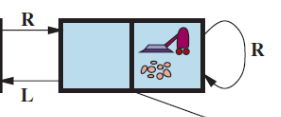

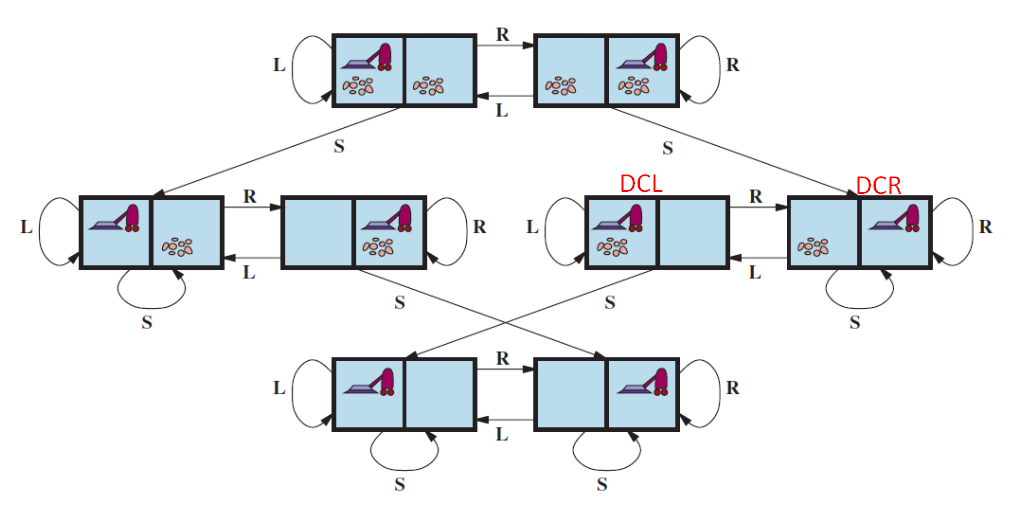

In [45]:
print(vp1.result("DCR", 'Suck'),vp1.result("DCR", 'Left'),vp1.result("DCR", 'Right'))

DCR DCL DCR


In [46]:
cost=0
vp1.path_cost(cost, "DCR", 'Suck',"DCR")

1

Now we are ready to consider `VacuumProblemSolvingAgent` class

In [47]:
from src.vacuumProblemSolvingAgentClass import VacuumProblemSolvingAgent

In [48]:
print(initState, goalState)

DDL ['CCL', 'CCR']


In [49]:
vpsa1=VacuumProblemSolvingAgent(initState,vacuumWorldGraph,goalState)

In [50]:
vpsa1.state # our Agent at the initial state

'DDL'

In [51]:
vpsa1.formulate_problem(vpsa1.state,vpsa1.goal).actions("DCR")

['Suck', 'Left', 'Right']

With **BFS** we choose a node, n, with minimum value of some evaluation function, f(n).

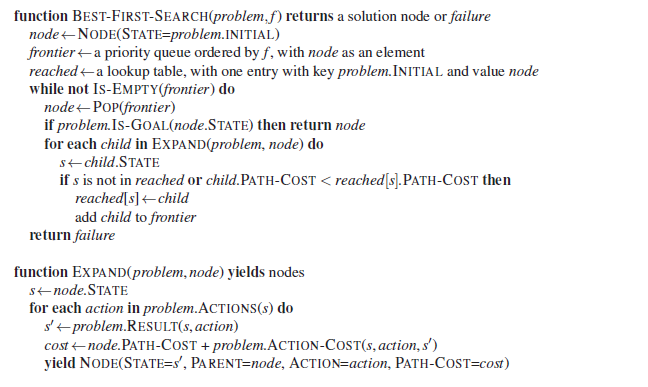

In [52]:
from src.PS_agentPrograms import BestFirstSearchAgentProgram

In [53]:
BFSAP1=BestFirstSearchAgentProgram()

In [54]:
vp1 # instance of vacuum Problem

In [55]:
vp1.initial

'DDL'

In [56]:
seq=BFSAP1(vp1)

<Node DDL>
<Node CDL>
<Node CDR>
<Node CCR>


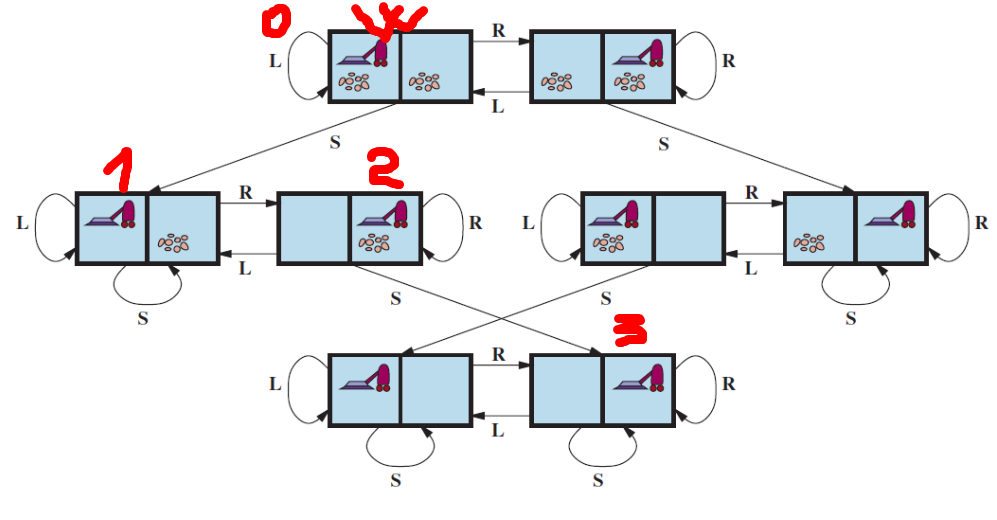

Now we can create the derived class `VacuumProblemSolvingAgentSMART` from VacuumProblemSolvingAgent to add AP and implement the Search.

!!! Explore the content of the `VacuumProblemSolvingAgentSMART class`

In [57]:
from src.agents import ProblemSolvingNavAgentBFS

In [58]:
BFSagent1=ProblemSolvingNavAgentBFS(initState,vacuumWorldGraph,goalState)

In [59]:
BFSagent1.seq # no solution at the very begining

[]

In [60]:
BFSagent1("CDR") # the  __call__ method with the percept as a parameter

<Node CDR>
<Node CCR>
<Node CCL>
Solution (a sequence of actions) from the initial state to a goal: ['CCR', 'CCL']
<Node CCL>
<Node CCR>
Solution (a sequence of actions) from the initial state to a goal: ['CCR']


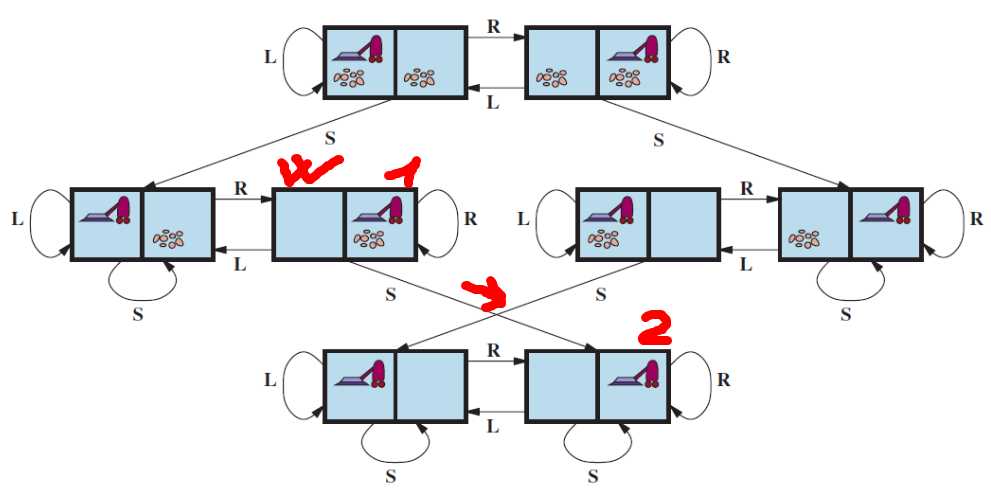

In [61]:
BFSagent1("CCR")

I have already don my work. Find someone else


In [62]:
BFSagent2=ProblemSolvingNavAgentBFS("DDL",vacuumWorldGraph,goalState)

In [ ]:
BFSagent2("CDL")

<Node CDL>
<Node CDR>
<Node CCR>
<Node CCL>


#### SPS Agent for the Romania Navigation Problem

In [ ]:
romaniaGraph.graph_dict

{'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
 'Bucharest': {'Urziceni': 85, 'Pitesti': 101, 'Giurgiu': 90, 'Fagaras': 211},
 'Craiova': {'Drobeta': 120, 'Rimnicu': 146, 'Pitesti': 138},
 'Drobeta': {'Mehadia': 75, 'Craiova': 120},
 'Eforie': {'Hirsova': 86},
 'Fagaras': {'Sibiu': 99, 'Bucharest': 211},
 'Hirsova': {'Urziceni': 98, 'Eforie': 86},
 'Iasi': {'Vaslui': 92, 'Neamt': 87},
 'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
 'Oradea': {'Zerind': 71, 'Sibiu': 151},
 'Pitesti': {'Rimnicu': 97, 'Bucharest': 101, 'Craiova': 138},
 'Rimnicu': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
 'Urziceni': {'Vaslui': 142, 'Bucharest': 85, 'Hirsova': 98},
 'Zerind': {'Arad': 75, 'Oradea': 71},
 'Sibiu': {'Arad': 140, 'Fagaras': 99, 'Oradea': 151, 'Rimnicu': 80},
 'Timisoara': {'Arad': 118, 'Lugoj': 111},
 'Giurgiu': {'Bucharest': 90},
 'Mehadia': {'Drobeta': 75, 'Lugoj': 70},
 'Vaslui': {'Iasi': 92, 'Urziceni': 142},
 'Neamt': {'Iasi': 87}}

In [ ]:
initState="Arad"
goalState="Bucharest"

In [ ]:
rnp1=GraphProblem(initState,goalState,romaniaGraph)

In [ ]:
rnp1.actions(initState) #action = move to the city .....

['Zerind', 'Sibiu', 'Timisoara']

In [ ]:
rnp1.result(initState,"Zerind") # if from Arad we are moving to Zerind -> we will be there

'Zerind'

Now we need to create the `navProblemSolvingAgent class` with its own *formulate_problem* method (to override it for the Graph Problem instance).

Also we will add the `run()` method for the whole process (with ability to process multiple goals).

!!! Explore the `navProblemSolvingAgent class`

In [ ]:
from src.agents import ProblemSolvingNavAgentBFS

In [ ]:
BFSnavAgent1=ProblemSolvingNavAgentBFS(initState,romaniaGraph,goalState)

In [ ]:
BFSnavAgent1.state

'Arad'

In [ ]:
BFSnavAgent1.formulate_goal(BFSnavAgent1.state)

'Bucharest'

In [ ]:
BFSnavAgent1('Sibiu')

<Node Sibiu>
<Node Arad>
<Node Fagaras>
<Node Bucharest>
Solution (a sequence of actions) from the initial state to a goal: ['Fagaras', 'Bucharest']


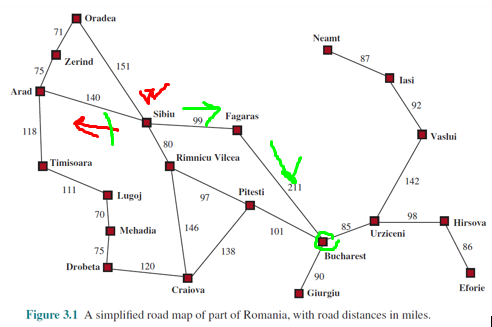

In [ ]:
BFSnavAgent2=ProblemSolvingNavAgentBFS(initState,romaniaGraph,goalState)

In [ ]:
BFSnavAgent2.run()

goal list: Bucharest
I have the only goal = Bucharest
<Node Arad>
<Node Sibiu>
<Node Fagaras>
<Node Bucharest>
Solution (a sequence of actions) from the initial state to a goal: ['Sibiu', 'Fagaras', 'Bucharest']


Let's create the environment for the Romania Map

In [ ]:
from src.naigationEnvironmentClass import NavigationEnvironment

In [ ]:
re1=NavigationEnvironment(romaniaGraph)

In [ ]:
re1.status.graph_dict

{'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
 'Bucharest': {'Urziceni': 85, 'Pitesti': 101, 'Giurgiu': 90, 'Fagaras': 211},
 'Craiova': {'Drobeta': 120, 'Rimnicu': 146, 'Pitesti': 138},
 'Drobeta': {'Mehadia': 75, 'Craiova': 120},
 'Eforie': {'Hirsova': 86},
 'Fagaras': {'Sibiu': 99, 'Bucharest': 211},
 'Hirsova': {'Urziceni': 98, 'Eforie': 86},
 'Iasi': {'Vaslui': 92, 'Neamt': 87},
 'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
 'Oradea': {'Zerind': 71, 'Sibiu': 151},
 'Pitesti': {'Rimnicu': 97, 'Bucharest': 101, 'Craiova': 138},
 'Rimnicu': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
 'Urziceni': {'Vaslui': 142, 'Bucharest': 85, 'Hirsova': 98},
 'Zerind': {'Arad': 75, 'Oradea': 71},
 'Sibiu': {'Arad': 140, 'Fagaras': 99, 'Oradea': 151, 'Rimnicu': 80},
 'Timisoara': {'Arad': 118, 'Lugoj': 111},
 'Giurgiu': {'Bucharest': 90},
 'Mehadia': {'Drobeta': 75, 'Lugoj': 70},
 'Vaslui': {'Iasi': 92, 'Urziceni': 142},
 'Neamt': {'Iasi': 87}}

In [ ]:
BFSnavAgent3=ProblemSolvingNavAgentBFS(initState,romaniaGraph,goalState)

When we add the PS Agent into the Nav.Env. it should run its call() method 

In [ ]:
re1.add_thing(BFSnavAgent3)

<Node Arad>
<Node Sibiu>
<Node Fagaras>
<Node Bucharest>
Solution (a sequence of actions) from the initial state to a goal: ['Sibiu', 'Fagaras', 'Bucharest']
The Agent in Arad with performance 20


In [ ]:
re1.step()

Agent decided to do Sibiu.
Agent in Sibiu with performance = 19


In [ ]:
re1.step()

Agent decided to do Fagaras.
Agent in Fagaras with performance = 18


In [ ]:
re1.step()

Agent decided to do Bucharest.
Agent in Bucharest with performance = 17
Agent reached the goal: Bucharest


In [ ]:
re1.step()

There is no one here who could work...


In [ ]:
BFSnavAgent4=ProblemSolvingNavAgentBFS("Sibiu",romaniaGraph,goalState)

In [ ]:
re1.add_thing(BFSnavAgent4)

<Node Sibiu>
<Node Arad>
<Node Fagaras>
<Node Bucharest>
Solution (a sequence of actions) from the initial state to a goal: ['Fagaras', 'Bucharest']
The Agent in Sibiu with performance 20


In [ ]:
re1.run()

step 1:
Agent decided to do Fagaras.
Agent in Fagaras with performance = 19
step 2:
Agent decided to do Bucharest.
Agent in Bucharest with performance = 18
Agent reached the goal: Bucharest


Now let's imagine that our Agent needs to visit *Pitesti* on its way to *Bucharest*.

**!!!** This means we need to arrange the **set of goals**: [Pitesti,Bucharest]

In [ ]:
multyGoalState=['Pitesti','Bucharest']
multyGoalState

['Pitesti', 'Bucharest']

In [ ]:
BFSnavAgent5=ProblemSolvingNavAgentBFS(initState,romaniaGraph,multyGoalState)

In [ ]:
BFSnavAgent5.goal

['Pitesti', 'Bucharest']

In [ ]:
re1.add_thing(BFSnavAgent5)

<Node Arad>
<Node Sibiu>
<Node Fagaras>
<Node Bucharest>
<Node Giurgiu>
<Node Oradea>
<Node Pitesti>
Solution (a sequence of actions) from the initial state to a goal: ['Sibiu', 'Fagaras', 'Bucharest', 'Pitesti']
<Node Pitesti>
<Node Bucharest>
Solution (a sequence of actions) from the initial state to a goal: ['Bucharest']
The Agent in Arad with performance 20


In [ ]:
re1.run()

step 1:
Agent decided to do Sibiu.
Agent in Sibiu with performance = 19
step 2:
Agent decided to do Fagaras.
Agent in Fagaras with performance = 18
step 3:
Agent decided to do Bucharest.
Agent in Bucharest with performance = 17
step 4:
Agent decided to do Pitesti.
Agent in Pitesti with performance = 16
step 5:
Agent decided to do Bucharest.
Agent in Bucharest with performance = 15
Agent reached all goals


## !!! Task. Treasure Maze

1. Model a Maze Problem by having a node for a starting point, a finishing point, dead ends, and all the points in the maze where more than one path can be taken (or the Agent should turn around), and then connecting the vertices according to the paths in the maze

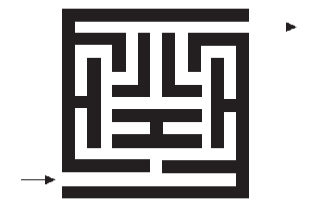

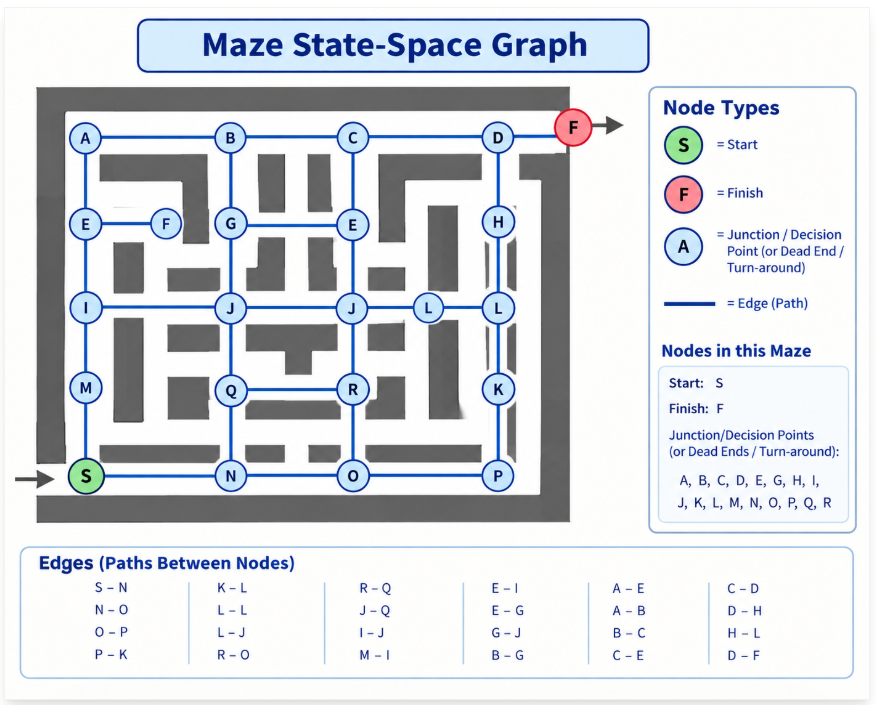

2. Add Treasures to the Maze

There are four types of treasures that may be placed throughout the maze:

* 🪙 Pile of Gold 😍
* 🔷 Diamond
* 🍕 Flyer for 100 Free Pizzas
* 🎉 20 Extra Points for the CS3220 Final Exam

**Treasure Placement Rules**
* Treasures are placed randomly at valid points in the maze.
* A treasure cannot be placed at the starting point.
* A treasure cannot be placed at the finishing point.
* No two treasures can occupy the same point.
* Each treasure should be associated with a vertex (node) in the graph.
* A vertex may contain at most one treasure.

3. Initially the Agent's performace is 50% of the number of nodes. One executed action is -1 from performace

4. Agent's actions: **advance, left, right**

5. The agent must grab one treasure. 

Then redefine its goal to find the exit 🏠.

**!!! Hint-1:** the Treasure maze == an Environmnet

We want **the treasures to affect the problem-solving objective**, there are several possible goal-state definitions (for 3 versions of the implementation)

| Version                 | Goal State                                                         |
| ----------------------- | ------------------------------------------------------------------ |
| **Basic**               | Reach the finish                                                   |
| **Treasure collection** | Collect ALL treasures and reach the finish                         |
| **Specific treasure**   | Find a particular treasure and then reach the finish               |


**!!! Hint-2:** if the agent reaches the finishing point after collecting ALL treasures in the maze.

The goal state is satisfied only when:

🪙 The pile of gold has been collected.

🔷 The diamond has been collected.

🍕 The 100-free-pizza flyer has been collected.

🎉 The 20 extra CS3220 points have been collected.

🏁 The agent has reached the Finish point.  

If the agent's state is represented as:

*State = (Current Position, Treasures Collected)*

then the goal state is:

*Goal = (Finish, {Gold, Diamond, Pizza, Extra Points})*

**!!!** Important implication for the "Treasure collection" version:

The agent cannot stop when it reaches the finish if it has not collected all 4 treasures.

## Solution: Treasure Maze

### 1. The maze as a graph (state space)

* A node for the start **S**, the finish **F** 🏠, the dead end **F2** and every junction / turning point; every edge is a corridor of the maze (cost = 1).
* The picture of the task repeats 4 labels, so the second copy (reading top-to-bottom, left-to-right) is named **E2, F2, J2, L2**.
* `MazeGraph` (derived from `Graph`) also keeps the location (column, row) of every node: it gives the direction (N/E/S/W) of every corridor, which the Agent needs for the relative actions *advance, left, right*.

!!! Explore `data/treasureMazeData.py` and `src/mazeGraphClass.py`

In [ ]:
from data.treasureMazeData import mazeData, mazeLocations, mazeStart, mazeFinish, startHeading, treasureTypes
from src.mazeGraphClass import MazeGraph

mazeGraph = MazeGraph(mazeData, mazeLocations)
print(len(mazeGraph.nodes()), "nodes:", sorted(mazeGraph.nodes()))
print("dead ends:", sorted(n for n in mazeGraph.nodes() if len(mazeGraph.get(n)) == 1))
mazeGraph.get('J2')

23 nodes: ['A', 'B', 'C', 'D', 'E', 'E2', 'F', 'F2', 'G', 'H', 'I', 'J', 'J2', 'K', 'L', 'L2', 'M', 'N', 'O', 'P', 'Q', 'R', 'S']
dead ends: ['F', 'F2']


{'R': 1, 'L': 1, 'E2': 1, 'J': 1}

In [ ]:
# from S looking to the East the Agent sees N; to the West of S there is a wall
mazeGraph.neighbor('S', 'E'), mazeGraph.neighbor('S', 'W'), mazeGraph.direction('J2', 'E2')

('N', None, 'N')

### 2. The Treasure Maze == an Environment

`TreasureMazeEnvironment(environmentPro)`: the maze graph is `status`, the treasures are `things`, the Agent is in `agents`.

Treasure placement rules: random valid points, not at the start, not at the finish, at most one treasure per node.

!!! Explore `src/treasureMazeEnvironmentClass.py` and `src/treasureClass.py`

In [ ]:
import random
from src.treasureMazeEnvironmentClass import TreasureMazeEnvironment
from src.treasureClass import Treasure

def newMaze(seed=3):
    random.seed(seed) # the same seed -> the same treasures (to compare the versions); use seed=None for a new random maze
    return TreasureMazeEnvironment(mazeGraph, mazeStart, mazeFinish, list(treasureTypes))

tm1 = newMaze()
tm1.treasures_map()

{'G': 'Gold', 'P': 'Diamond', 'O': 'Pizza', 'E': 'ExtraPoints'}

In [ ]:
tm1.add_thing(Treasure('Gold'), mazeStart) # a treasure can't be placed at the starting point
tm1.add_thing(Treasure('Gold'), 'G')       # node G already has a treasure

Can't place Pile of Gold at S
Can't place Pile of Gold at G


### 3. The Problem: `MazeProblem(Problem)`

* *State* = (Current Position, Heading, Treasures Collected)
* *Actions*: **advance** (go along the corridor in front of the Agent), **left**, **right** (turn 90°). Turning around at a dead end = two turns.
* *Goal test*: the position is the goal node **and** all wanted treasures are collected.

!!! Explore `src/mazeProblemClass.py`

In [ ]:
from src.mazeProblemClass import MazeProblem

mp1 = MazeProblem((mazeStart, startHeading, frozenset()), mazeFinish, mazeGraph)
print(mp1.actions(mp1.initial))
print(mp1.result(mp1.initial, 'advance'), mp1.result(mp1.initial, 'left'))
mp1.goal_test(('F', 'E', frozenset()))

['advance', 'left', 'right']
('N', 'E', frozenset()) ('S', 'N', frozenset())


True

### 4. The Agent: `MazeProblemSolvingAgent` + Breadth-First Search

* Initial performance = 50% of the number of nodes; one executed action = -1 from performance; the Agent dies when the performance is 0.
* The search is the uninformed **Breadth-First Search** (`BreadthFirstSearchAgentProgram` in `src/PS_agentPrograms.py`, FIFO frontier): every action costs 1, so the plan has the fewest actions.

!!! Explore `src/mazeProblemSolvingAgentClass.py`

#### Version 1. Basic: reach the finish

In [ ]:
from src.agents import ProblemSolvingMazeAgentBFS

basicAgent = ProblemSolvingMazeAgentBFS(mazeStart, mazeGraph, mazeFinish, 'Basic')
basicAgent.performance

11

In [ ]:
tm1.add_thing(basicAgent)
tm1.run(20)

The Agent in S facing E with performance 11
Agent's goal: F
Solution (a sequence of actions) from the current state to the goal: ['advance', 'advance', 'advance', 'left', 'advance', 'advance', 'advance', 'advance', 'right', 'advance']
step 1:
Agent decided to do advance.
Agent in N facing E with performance = 10
step 2:
Agent decided to do advance.
Agent in O facing E with performance = 9
step 3:
Agent decided to do advance.
Agent in P facing E with performance = 8
step 4:
Agent decided to do left.
Agent in P facing N with performance = 7
step 5:
Agent decided to do advance.
Agent in K facing N with performance = 6
step 6:
Agent decided to do advance.
Agent in L2 facing N with performance = 5
step 7:
Agent decided to do advance.
Agent in H facing N with performance = 4
step 8:
Agent decided to do advance.
Agent in D facing N with performance = 3
step 9:
Agent decided to do right.
Agent in D facing E with performance = 2
step 10:
Agent decided to do advance.
Agent in F facing E with per

#### Version 2. Specific treasure: grab one treasure, then re-define the goal: find the exit 🏠

The first goal is the node of the treasure. When the treasure is grabbed, the Agent re-defines its goal (the exit) and searches again.

In [ ]:
tm2 = newMaze()
diamondAgent = ProblemSolvingMazeAgentBFS(mazeStart, mazeGraph, mazeFinish, 'Specific treasure', 'Diamond')
tm2.add_thing(diamondAgent)
tm2.run(20)

The Agent in S facing E with performance 11
Agent's goal: P
Solution (a sequence of actions) from the current state to the goal: ['advance', 'advance', 'advance']
step 1:
Agent decided to do advance.
Agent in N facing E with performance = 10
step 2:
Agent decided to do advance.
Agent in O facing E with performance = 9
step 3:
Agent decided to do advance.
Agent in P facing E with performance = 8
Agent grabbed the Diamond!
Agent's goal: F
Solution (a sequence of actions) from the current state to the goal: ['left', 'advance', 'advance', 'advance', 'advance', 'right', 'advance']
step 4:
Agent decided to do left.
Agent in P facing N with performance = 7
step 5:
Agent decided to do advance.
Agent in K facing N with performance = 6
step 6:
Agent decided to do advance.
Agent in L2 facing N with performance = 5
step 7:
Agent decided to do advance.
Agent in H facing N with performance = 4
step 8:
Agent decided to do advance.
Agent in D facing N with performance = 3
step 9:
Agent decided to do r

In [ ]:
tm3 = newMaze()
anyTreasureAgent = ProblemSolvingMazeAgentBFS(mazeStart, mazeGraph, mazeFinish, 'Specific treasure') # target=None -> the nearest treasure
tm3.add_thing(anyTreasureAgent)
tm3.run(20)

The Agent in S facing E with performance 11
Agent's goal: ['G', 'P', 'O', 'E']
Solution (a sequence of actions) from the current state to the goal: ['advance', 'advance']
step 1:
Agent decided to do advance.
Agent in N facing E with performance = 10
step 2:
Agent decided to do advance.
Agent in O facing E with performance = 9
Agent grabbed the Flyer for 100 Free Pizzas!
Agent's goal: F
Solution (a sequence of actions) from the current state to the goal: ['advance', 'left', 'advance', 'advance', 'advance', 'advance', 'right', 'advance']
step 3:
Agent decided to do advance.
Agent in P facing E with performance = 8
step 4:
Agent decided to do left.
Agent in P facing N with performance = 7
step 5:
Agent decided to do advance.
Agent in K facing N with performance = 6
step 6:
Agent decided to do advance.
Agent in L2 facing N with performance = 5
step 7:
Agent decided to do advance.
Agent in H facing N with performance = 4
step 8:
Agent decided to do advance.
Agent in D facing N with performa

#### Version 3. Treasure collection: Goal = (Finish, {Gold, Diamond, Pizza, ExtraPoints})

One search over the states (position, heading, treasures collected): the Agent can't stop at F before it has all 4 treasures.

!!! With the initial performance = 11 the optimal plan is usually longer than 11 actions, so the Agent dies on the way.

In [ ]:
tm4 = newMaze()
collectorAgent = ProblemSolvingMazeAgentBFS(mazeStart, mazeGraph, mazeFinish, 'Treasure collection')
tm4.add_thing(collectorAgent)
tm4.run(30)

The Agent in S facing E with performance 11
Agent's goal: F
Solution (a sequence of actions) from the current state to the goal: ['left', 'advance', 'advance', 'advance', 'advance', 'right', 'advance', 'right', 'advance', 'advance', 'advance', 'advance', 'left', 'advance', 'advance', 'left', 'advance', 'advance', 'advance', 'advance', 'right', 'advance']
step 1:
Agent decided to do left.
Agent in S facing N with performance = 10
step 2:
Agent decided to do advance.
Agent in M facing N with performance = 9
step 3:
Agent decided to do advance.
Agent in I facing N with performance = 8
step 4:
Agent decided to do advance.
Agent in E facing N with performance = 7
Agent grabbed the 20 Extra Points for the CS3220 Final Exam!
step 5:
Agent decided to do advance.
Agent in A facing N with performance = 6
step 6:
Agent decided to do right.
Agent in A facing E with performance = 5
step 7:
Agent decided to do advance.
Agent in B facing E with performance = 4
step 8:
Agent decided to do right.
Agent

In [ ]:
# experiment: the same maze, but the Agent gets more performance than the rules give
tm5 = newMaze()
collectorAgent2 = ProblemSolvingMazeAgentBFS(mazeStart, mazeGraph, mazeFinish, 'Treasure collection')
collectorAgent2.performance = 30
tm5.add_thing(collectorAgent2)
tm5.run(30)
collectorAgent2.escaped, collectorAgent2.bag

The Agent in S facing E with performance 30
Agent's goal: F
Solution (a sequence of actions) from the current state to the goal: ['left', 'advance', 'advance', 'advance', 'advance', 'right', 'advance', 'right', 'advance', 'advance', 'advance', 'advance', 'left', 'advance', 'advance', 'left', 'advance', 'advance', 'advance', 'advance', 'right', 'advance']
step 1:
Agent decided to do left.
Agent in S facing N with performance = 29
step 2:
Agent decided to do advance.
Agent in M facing N with performance = 28
step 3:
Agent decided to do advance.
Agent in I facing N with performance = 27
step 4:
Agent decided to do advance.
Agent in E facing N with performance = 26
Agent grabbed the 20 Extra Points for the CS3220 Final Exam!
step 5:
Agent decided to do advance.
Agent in A facing N with performance = 25
step 6:
Agent decided to do right.
Agent in A facing E with performance = 24
step 7:
Agent decided to do advance.
Agent in B facing E with performance = 23
step 8:
Agent decided to do right.

(True, ['ExtraPoints', 'Gold', 'Pizza', 'Diamond'])

### Web App

```
streamlit run lab3app_treasureMaze.py
```

## Screeshots of Web App as examples

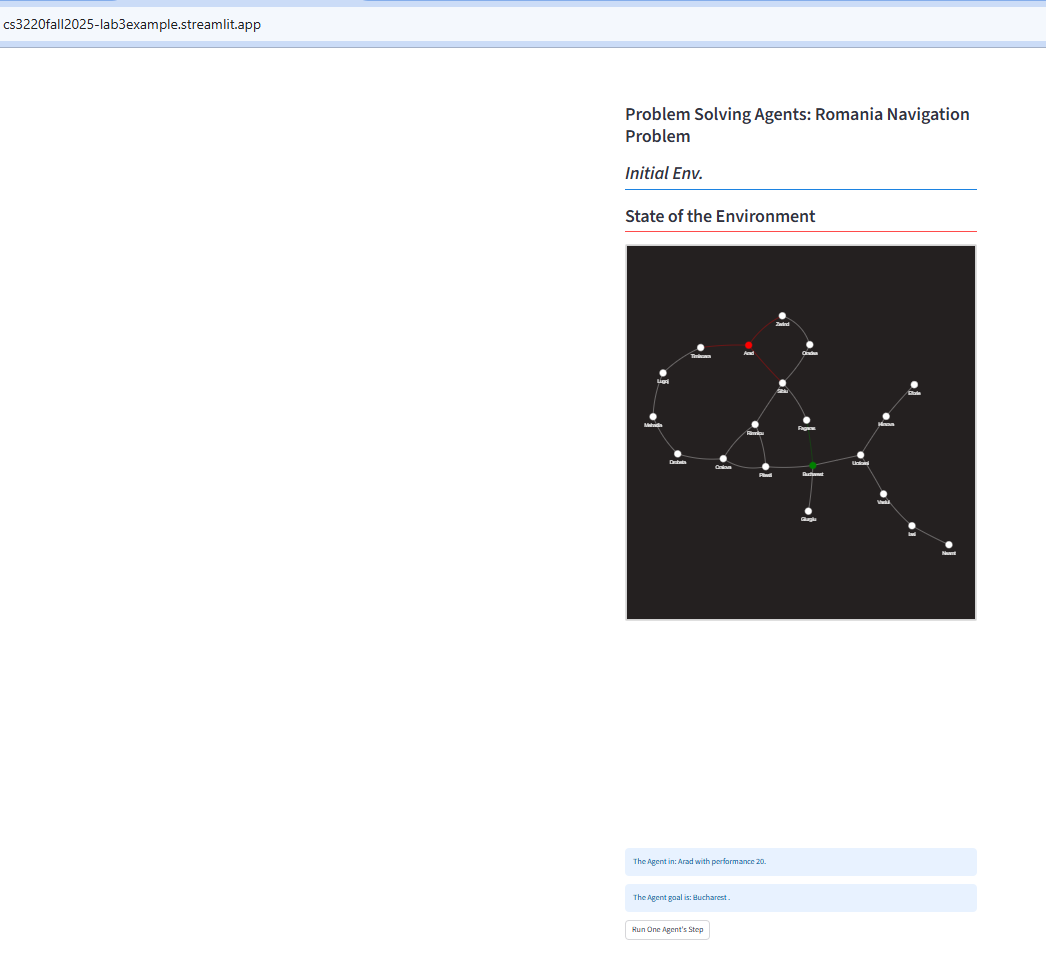

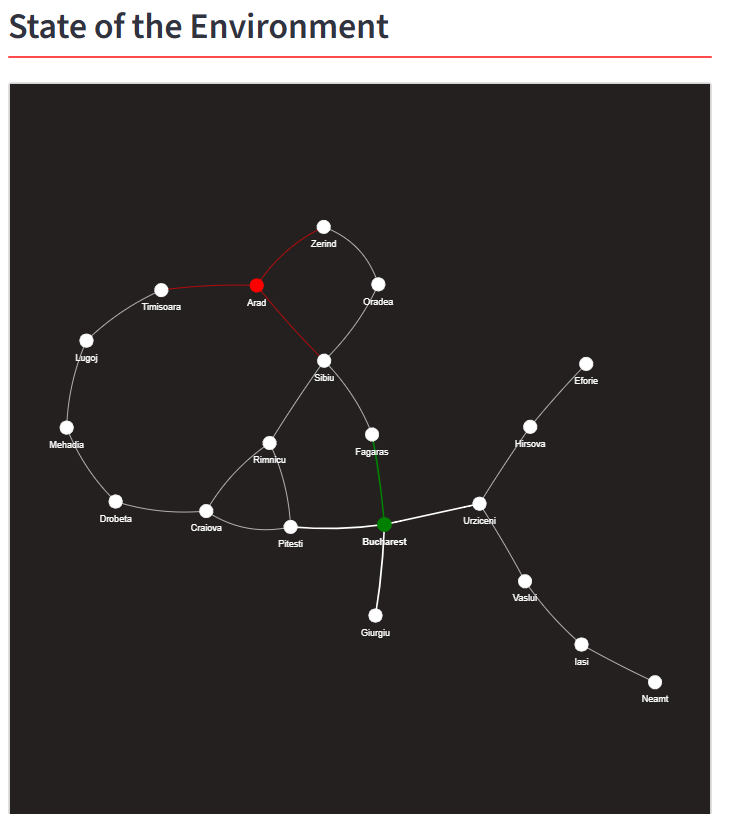
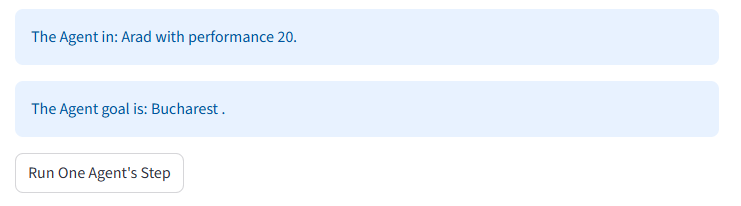

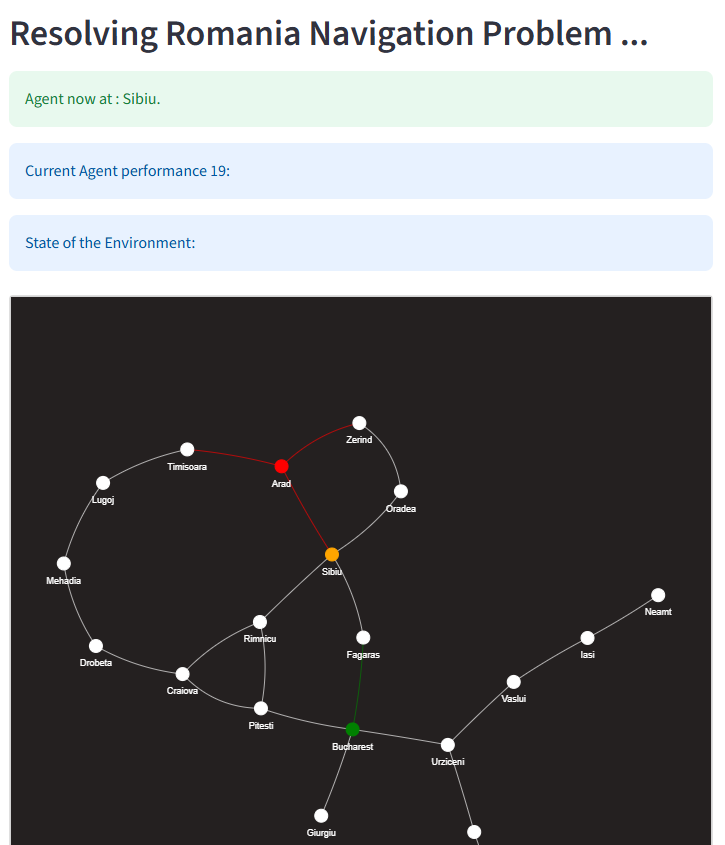
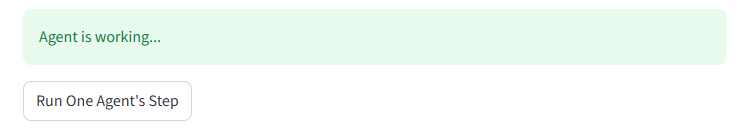

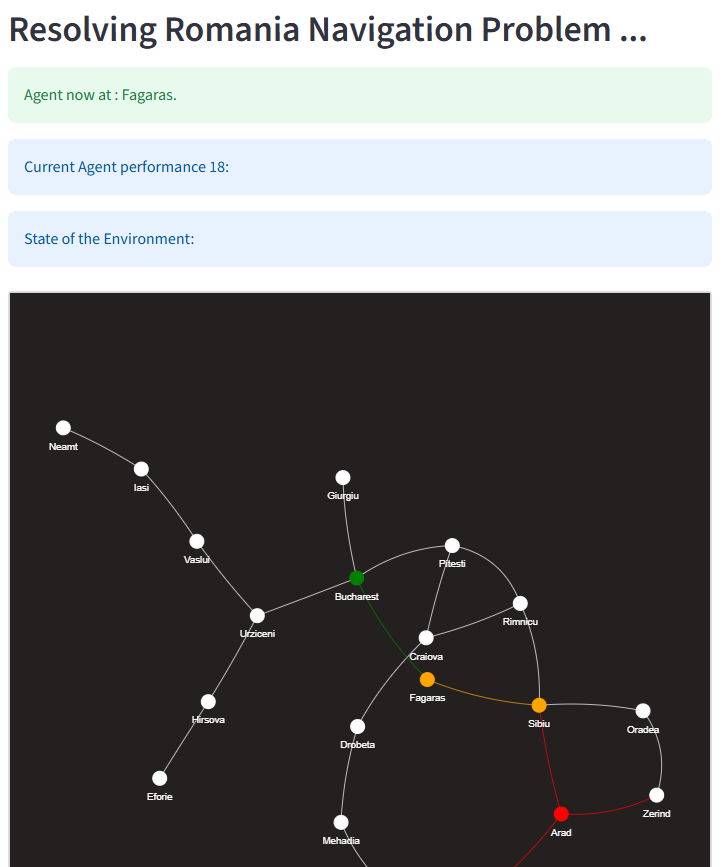

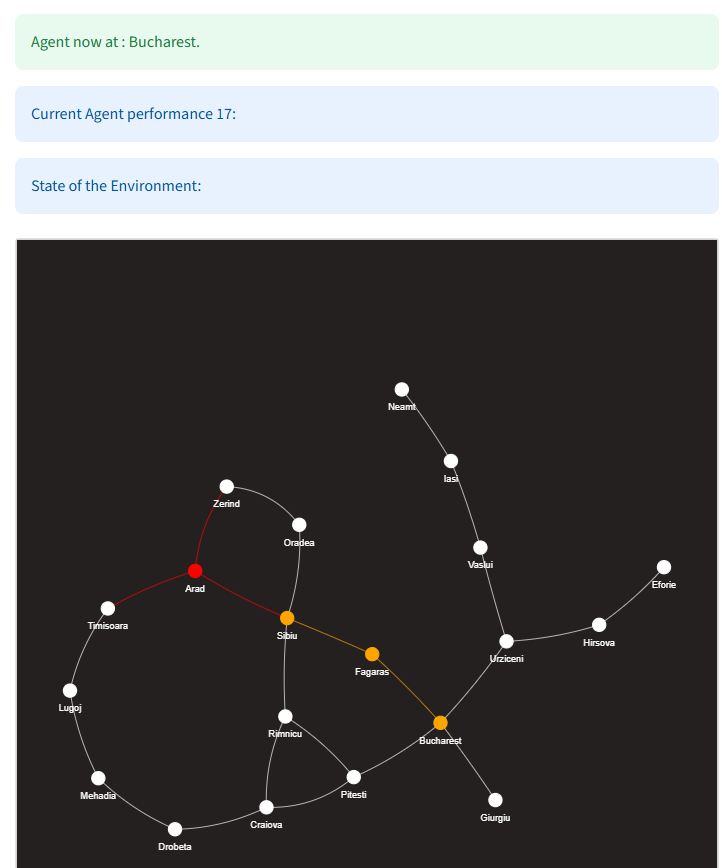